#**Case Study 3: Brain Cancer Segmentation**

#**All General Imports**

In [128]:
# imports
import os
import cv2
import glob
import pdb
import json
import sys
import timeit
import platform
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from os.path import basename

#**Platform Settings**

In [95]:
colab_active = 'google.colab' in sys.modules
print("Colab Active: ", colab_active)
# Operating System
OS = platform.system()                           # returns 'Windows', 'Linux', etc

Colab Active:  True


#**All Keras Imports**

In [96]:
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.utils import normalize, to_categorical
from tensorflow.keras.models import model_from_json
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda

#**All Functions Definitions**

In [97]:
def data_download(file_to_download, gdrive_code, OS, uncompress=True):

  if not os.path.exists(file_to_download):
    url = f"https://drive.google.com/uc?id={gdrive_code}"
    os.system(f'gdown "{url}" -O "{file_to_download}"')
    if OS == "Linux" and uncompress:
        os.system(f'unzip -o -n "{file_to_download}" -d "./"')
    return True
  else:
    return None

#**All Data Downloads**

In [98]:
start_time = timeit.default_timer()
# Operating System
OS = platform.system()                           # returns 'Windows', 'Linux', etc

os.system('pip install --upgrade --no-cache-dir gdown')

#out = data_download("./brain_tumor_dataset_1.zip", "1IlfIKVCF2nnYndfZWsE7NHPE0si2bof1", OS)
out = data_download("./brain_tumor_dataset_2.zip", "1dYZ4GMfSeCEdnw-JqlgNUsMajHzLCqWp", OS)
print("Elapsed Time: ", timeit.default_timer() - start_time)

Elapsed Time:  2.4931721279999692


#**Brain Tumor Classification**

#**All Globals**

In [99]:
training = True
dataset_path = "./brain_tumor_dataset_2/Br35H-Mask-RCNN/"
predicted_images = "./predicted_images/"
train_folder = "TRAIN/"
val_folder = "VAL/"
test_folder = "TEST/"
annotations_train_file = dataset_path+train_folder+'annotations_train.json'
annotations_val_file = dataset_path+val_folder+'annotations_val.json'
annotations_test_file = dataset_path+test_folder+'annotations_test.json'
masks_train_folder = dataset_path+train_folder+'train_target_masks/'
masks_val_folder = dataset_path+val_folder+'val_target_masks/'
masks_test_folder = dataset_path+test_folder+'test_target_masks/'
input_data_type = "float"
target_data_type = "int"
n_rows_to_plot = 5
n_cols_to_plot = 5

#**Hyperparameters**

In [100]:
neural_model = 'brain_unet'
epochs = 100
batch_size = 32
width = 256
height = 256
channels = 1
summary = False
split_val = False

#**Initializations**

In [101]:
np.random.seed(42)
folders = [dataset_path+train_folder, dataset_path+val_folder, dataset_path+test_folder]
masks_folders = [masks_train_folder, masks_val_folder, masks_test_folder]

#**Functions Definitions**

In [102]:
def json_to_masks(input_images_folder, annotations_path, masks_folder):
  '''
  Converts Json Annotations Files into Img annotation Masks
  '''

  with open(annotations_path) as json_file:
      data = json.load(json_file)

  input_images = glob.glob(input_images_folder + "*.jpg")

  for img in input_images:
    image = cv2.imread(img)
    dimensions = image.shape
    file_name = basename(img).split('.')[0]
    tmp = np.zeros(dimensions).astype('uint8')
    for d in data:
        if file_name == data[d]['filename'].replace(".jpg",""):
            if len(data[d]['regions'][0]['shape_attributes']) == 3:
                x_pixels = data[d]['regions'][0]['shape_attributes']['all_points_x']
                y_pixels = data[d]['regions'][0]['shape_attributes']['all_points_y']
                pts = []
                for i in range(len(x_pixels)):
                    pts.append([x_pixels[i], y_pixels[i]])
                ptss = np.array(pts)
                ptss = ptss.reshape((-1, 1, 2))
                isClosed = True
                tmp = cv2.fillPoly(tmp, [ptss], (255,255,255))
            elif len(data[d]['regions'][0]['shape_attributes']) == 6:
                center_coordinates = (data[d]['regions'][0]['shape_attributes']['cx'],
                                      data[d]['regions'][0]['shape_attributes']['cy'])
                axesLength = (int(data[d]['regions'][0]['shape_attributes']['rx']),
                              int(data[d]['regions'][0]['shape_attributes']['ry']))
                angle = data[d]['regions'][0]['shape_attributes']['theta']
                startAngle = 0
                endAngle = 360
                tmp = cv2.ellipse(tmp,
                                  center_coordinates,
                                  axesLength,
                                  angle,
                                  startAngle,
                                  endAngle,
                                  (255,255,255),
                                  thickness=-1)

    cv2.imwrite("{}.png".format(masks_folder+file_name), tmp.astype('uint8'))

def read_images(folders, is_mask = False):
  '''
  Reads all the Input or Masks Images
  '''
  datasets = []
  for f in folders:
    if is_mask is False:
      images = glob.glob(f+"*.jpg")
    else:
      images = glob.glob(f+"*.png")

    images.sort()
    dataset = []
    for img in images:
      image = cv2.imread(img, cv2.IMREAD_GRAYSCALE)
      image = image / 255
      image = cv2.resize(image, (width, height))
      if is_mask is True:
        image[image != 0] = 1
      dataset.append(image)

    datasets.append(dataset)

  return datasets

def data_shuffle(data_x, data_y):
  '''
  Data Shuffle
  '''

  indices = np.arange(data_x.shape[0])
  np.random.shuffle(indices)
  data_x = data_x[indices]
  data_y = data_y[indices]

  return (data_x, data_y)

def plot_images(dataset, n_rows_to_plot = 3, n_cols_to_plot = 5):
  fig = plt.figure(figsize=(10,5))
  i = 0
  for im in dataset:
      plt.axis("off")
      ax = fig.add_subplot(n_rows_to_plot, n_cols_to_plot, 1 + i, xticks=[], yticks=[])
      plt.imshow(im, cmap = "gray")
      i += 1
      if i >= n_rows_to_plot*n_cols_to_plot:
        break
  plt.show()


def jacard(y_true, y_pred):

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_c = K.flatten(y_true)
    y_pred_c = K.flatten(y_pred)

    intersection = K.sum(y_true_c * y_pred_c)

    return (intersection + 1.0) / (
        K.sum(y_true_c) + K.sum(y_pred_c) - intersection + 1.0
    )

def jacard_loss(y_true, y_pred):
    return -jacard(y_true,y_pred)

#**Preprocessing**

In [103]:
datasets  = read_images(folders)

train_set_x, val_set_x, test_set_x = datasets

train_set_x = np.asarray(train_set_x).astype(input_data_type)
val_set_x = np.asarray(val_set_x).astype(input_data_type)
test_set_x = np.asarray(test_set_x).astype(input_data_type)

#**Target Generation Converting Annotations into Masks**

Creates the masks folders if not present. If masks are not present, the masks generation process will start, otherwise, it will take already generated masks.

In [104]:
if os.path.isdir(masks_train_folder) is False:
  os.makedirs(masks_train_folder)
  json_to_masks(dataset_path+train_folder, annotations_train_file, masks_train_folder)

if os.path.isdir(masks_val_folder) is False:
  os.makedirs(masks_val_folder)
  json_to_masks(dataset_path+val_folder, annotations_val_file, masks_val_folder)

if os.path.isdir(masks_test_folder) is False:
  os.makedirs(masks_test_folder)
  json_to_masks(dataset_path+test_folder, annotations_test_file, masks_test_folder)

datasets  = read_images(masks_folders, True)

train_set_y, val_set_y, test_set_y = datasets

train_set_y = np.asarray(train_set_y).astype(target_data_type)
val_set_y = np.asarray(val_set_y).astype(target_data_type)
test_set_y = np.asarray(test_set_y).astype(target_data_type)

#**Data Shuffle**

In [105]:
train_set_x, train_set_y = data_shuffle(train_set_x, train_set_y)
val_set_x, val_set_y = data_shuffle(val_set_x, val_set_y)
test_set_x, test_set_y = data_shuffle(test_set_x, test_set_y)

print("Train X Shape: ", train_set_x.shape)
print("Train Y Shape: ", train_set_y.shape)
print("Val X Shape: ", val_set_x.shape)
print("Val Y Shape: ", val_set_y.shape)
print("Test X Shape: ", test_set_x.shape)
print("Test Y Shape: ", test_set_y.shape)

Train X Shape:  (500, 256, 256)
Train Y Shape:  (500, 256, 256)
Val X Shape:  (201, 256, 256)
Val Y Shape:  (201, 256, 256)
Test X Shape:  (100, 256, 256)
Test Y Shape:  (100, 256, 256)


#**Dataset Sample Visualization**

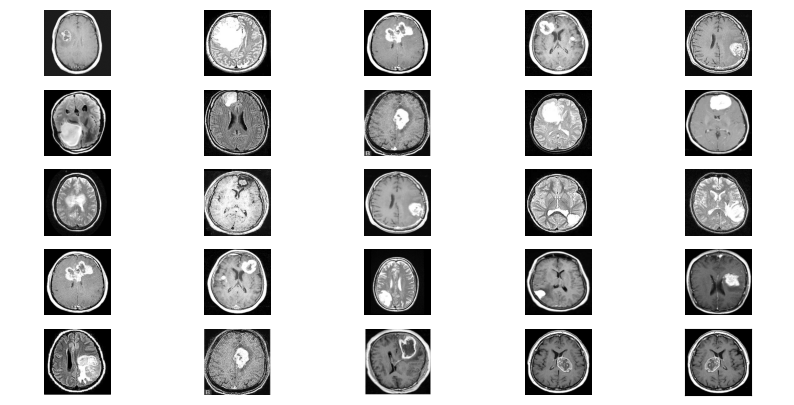

In [106]:
if OS!="Linux" or colab_active is True:
  plot_images(val_set_x, n_rows_to_plot, n_cols_to_plot)

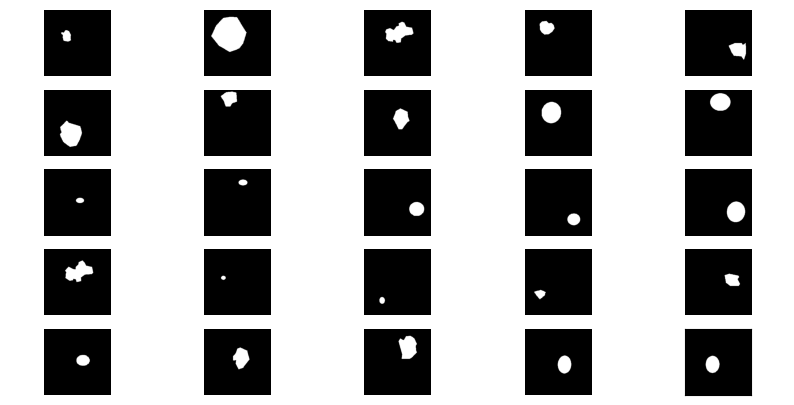

In [107]:
if OS!="Linux" or colab_active is True:
  plot_images(val_set_y, n_rows_to_plot, n_cols_to_plot)

#**Data Reshaping for the Training**

In [108]:
train_set_x = np.reshape(train_set_x, (len(train_set_x), height, width, channels))
train_set_y = np.reshape(train_set_y, (len(train_set_y), height, width, channels))
print("Train X Shape: ", train_set_x.shape)
print("Train Y Shape: ", train_set_y.shape)

Train X Shape:  (500, 256, 256, 1)
Train Y Shape:  (500, 256, 256, 1)


#**Model Definitions**

#**Segmentation Model Definition: Unet**

In [109]:
def unet(n_classes=2, height=256, width=256, channels=1, metrics = ['accuracy']):
    inputs = Input((height, width, channels))

    #Contraction path
    conv_1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    conv_1 = Dropout(0.1)(conv_1)
    conv_1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(conv_1)
    pool_1 = MaxPooling2D((2, 2))(conv_1)

    conv_2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(pool_1)
    conv_2 = Dropout(0.1)(conv_2)
    conv_2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(conv_2)
    pool_2 = MaxPooling2D((2, 2))(conv_2)

    conv_3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(pool_2)
    conv_3 = Dropout(0.1)(conv_3)
    conv_3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(conv_3)
    pool_3 = MaxPooling2D((2, 2))(conv_3)

    conv_4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(pool_3)
    conv_4 = Dropout(0.1)(conv_4)
    conv_4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(conv_4)
    pool_4 = MaxPooling2D(pool_size=(2, 2))(conv_4)

    conv_5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(pool_4)
    conv_5 = Dropout(0.2)(conv_5)
    conv_5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(conv_5)

    #Expansive path
    u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv_5)
    u6 = concatenate([u6, conv_4])
    conv_6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    conv_6 = Dropout(0.2)(conv_6)
    conv_6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(conv_6)

    u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv_6)
    u7 = concatenate([u7, conv_3])
    conv_7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    conv_7 = Dropout(0.1)(conv_7)
    conv_7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(conv_7)

    u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(conv_7)
    u8 = concatenate([u8, conv_2])
    conv_8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    conv_8 = Dropout(0.2)(conv_8)
    conv_8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(conv_8)

    u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(conv_8)
    u9 = concatenate([u9, conv_1], axis=3)
    conv_9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    conv_9 = Dropout(0.1)(conv_9)
    conv_9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(conv_9)

    if n_classes == 2:
      outputs = Conv2D(1, (1, 1), activation='sigmoid')(conv_9)
    elif n_classes > 2:
      outputs = Conv2D(n_classes, (1, 1), activation='softmax')(conv_9)

    model = Model(inputs=[inputs], outputs=[outputs])

    if n_classes == 2:
      model.compile(optimizer = Adam(learning_rate = 1e-4), loss = 'binary_crossentropy', metrics = metrics)
    elif n_classes > 2:
      model.compile(optimizer = Adam(learning_rate = 1e-4), loss = 'categorical_crossentropy', metrics = metrics)

    if summary:
      model.summary()

    return model

#**Model Compiling**

In [110]:
metrics=['accuracy', jacard]
n_classes = len(np.unique(train_set_y))        # Detect the number of classes within the target
brain_unet = unet(n_classes=n_classes, height = height, width = width, channels = channels, metrics = metrics)

#**Brain Segmentation Model Training**

In [111]:
if training is True:
  if split_val is True:
    brain_unet.fit(train_set_x, train_set_y, validation_split = 0.2, epochs = epochs, batch_size = batch_size)
  else:
    brain_unet.fit(train_set_x, train_set_y, validation_data = (val_set_x, val_set_y), epochs = epochs, batch_size = batch_size)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 105s 3s/step - accuracy: 0.6428 - jacard: 0.0452 - loss: 0.6195 - val_accuracy: 0.9408 - val_jacard: 0.0374 - val_loss: 0.4177
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 368ms/step - accuracy: 0.9188 - jacard: 0.0265 - loss: 0.3613 - val_accuracy: 0.9492 - val_jacard: 0.0491 - val_loss: 0.3282
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 351ms/step - accuracy: 0.9429 - jacard: 0.0533 - loss: 0.2301 - val_accuracy: 0.9500 - val_jacard: 0.0890 - val_loss: 0.2132
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 324ms/step - accuracy: 0.9452 - jacard: 0.0884 - loss: 0.1788 - val_accuracy: 0.9493 - val_jacard: 0.0884 - val_loss: 0.2718
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 320ms/step - accuracy: 0.9459 - jacard: 0.1116 - loss: 0.1673 - val_accuracy: 0.9493 - val_jacard: 0.0979 - val_loss: 0.2285
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 322ms/step - accuracy: 0.9466 - jacard: 0.1261 - loss: 0.1553 - val_accuracy: 0.9481 - val_jacard: 0.1029 - val_loss: 0.230

#**Brain Segmentation Model Saving**

In [113]:
if training is True:
  brain_unet.save_weights("./brain_segmentation_last_model.weights.h5")
  model_json = brain_unet.to_json()
  with open("./brain_segmentation_last_model.json", "w") as json_file:
    json_file.write(model_json)

#**Trained Brain Segmentation Model Loading**

In [119]:
with open("./brain_segmentation_last_model.json", 'r') as json_file:
    loaded_model_json = json_file.read()

brain_unet = model_from_json(
    loaded_model_json,
    custom_objects={'jacard': jacard}
)

brain_unet.load_weights(
    "./brain_segmentation_last_model.weights.h5"
)

print("Brain Segmentation Unet Loaded Successfully...")

brain_unet.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=[jacard]
)

if summary:
    brain_unet.summary()

Brain Segmentation Unet Loaded Successfully...


#**Test Set Images Visulization**

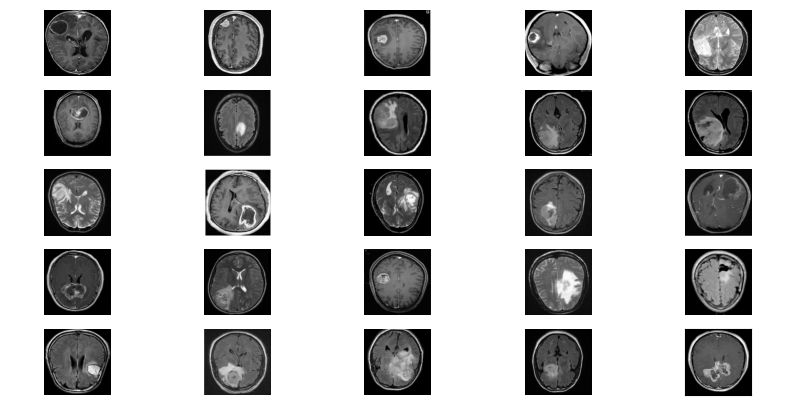

In [120]:
if OS!="Linux" or colab_active is True:
  plot_images(test_set_x, n_rows_to_plot, n_cols_to_plot)

#**Test Set Predictions Visualization**

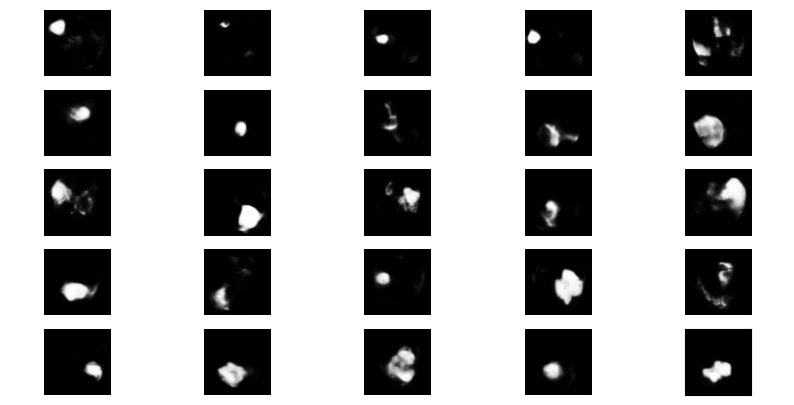

In [122]:
pred_list = []

for t in test_set_x:
  brain_predicted = (
      np.reshape(
          brain_unet.predict(
              np.reshape(t, (1, 256, 256, 1)),
              verbose=0
          ),
          (256, 256)
      ).astype(np.float32) * 255
  ).astype("uint8")

  pred_list.append(brain_predicted)

if OS != "Linux" or colab_active is True:
  plot_images(pred_list, n_rows_to_plot, n_cols_to_plot)

#**Thresholding**

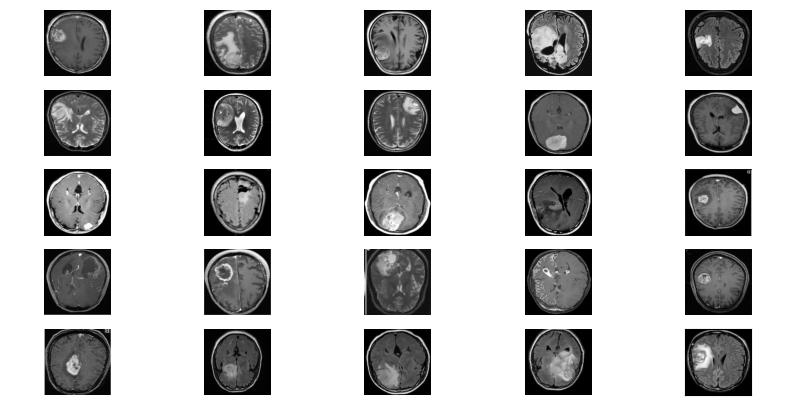

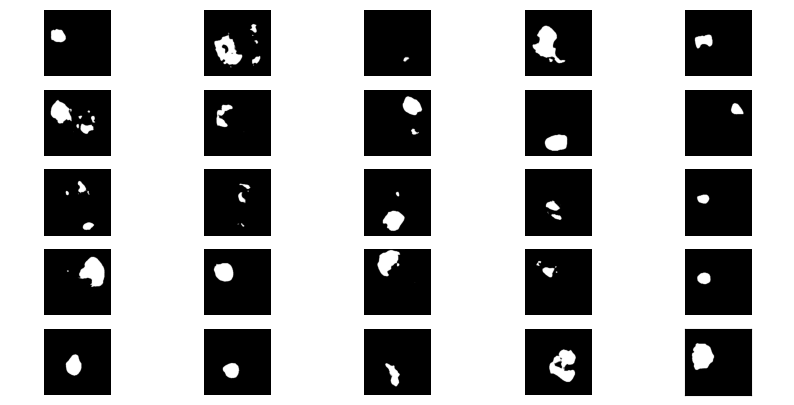

In [124]:
test_set = []
pred_list_ov = []
mask_list = []

if os.path.isdir(predicted_images) is False:
  os.makedirs(predicted_images)

images = glob.glob(dataset_path + test_folder + "*.jpg")
images.sort()

for i in range(len(images)):

  image = cv2.imread(images[i], cv2.IMREAD_GRAYSCALE)
  image = image / 255
  image = cv2.resize(image, (width, height))

  test_set.append(image)

  file_name = basename(images[i]).split('.')[0]

  brain_predicted = (
      np.reshape(
          brain_unet.predict(
              np.reshape(image, (1, 256, 256, 1)),
              verbose=0
          ),
          (256, 256)
      ).astype(np.float32) * 255
  ).astype("uint8")

  brain_predicted = cv2.cvtColor(
      brain_predicted,
      cv2.COLOR_GRAY2BGR
  )

  ret, mask = cv2.threshold(
      brain_predicted,
      120,
      255,
      cv2.THRESH_BINARY
  )

  white_pixels = np.where(
      (mask[:, :, 0] == 255) &
      (mask[:, :, 1] == 255) &
      (mask[:, :, 2] == 255)
  )

  mask[white_pixels] = [255, 255, 255]

  mask_list.append(mask)

  cv2.imwrite(
      predicted_images + file_name + "_mask.png",
      mask
  )

if OS != "Linux" or colab_active is True:
  plot_images(test_set, n_rows_to_plot, n_cols_to_plot)
  plot_images(mask_list, n_rows_to_plot, n_cols_to_plot)

# **Post-Processing Analysis**

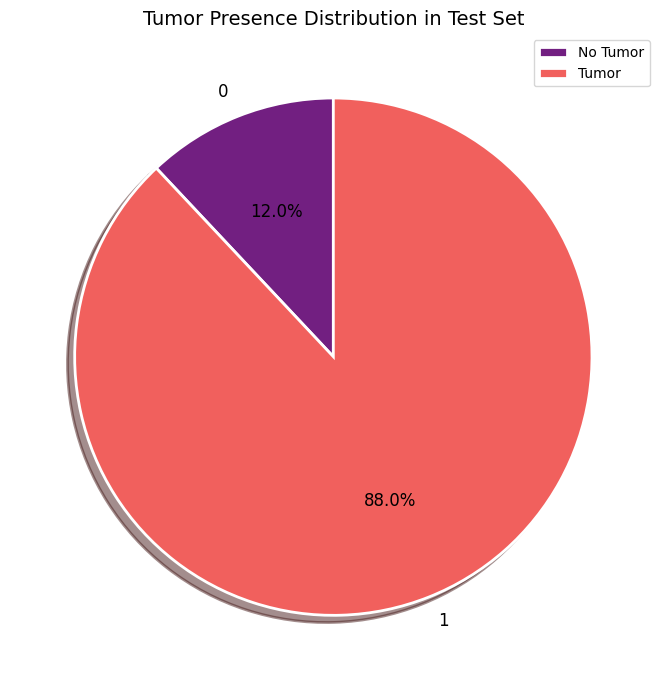

In [132]:
tumor_presence = []

min_tumor_area = 1000

for mask in mask_list:

    gray_mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(
        gray_mask,
        127,
        255,
        cv2.THRESH_BINARY
    )

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    largest_area = 0

    for cnt in contours:

        area = cv2.contourArea(cnt)

        if area > largest_area:
            largest_area = area

    if largest_area > min_tumor_area:
        tumor_presence.append(1)
    else:
        tumor_presence.append(0)

tumor_series = pd.Series(
    tumor_presence
).value_counts().sort_index()

plt.figure(figsize=(7,7))

tumor_series.plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    colors=sns.color_palette('magma', 2),
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 2
    },
    textprops={'fontsize': 12}
)

plt.title(
    "Tumor Presence Distribution in Test Set",
    fontsize=14
)

plt.ylabel('')

plt.legend(
    ['No Tumor', 'Tumor'],
    loc='upper right'
)

plt.tight_layout()

plt.show()

/tmp/ipykernel_15735/3283842238.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


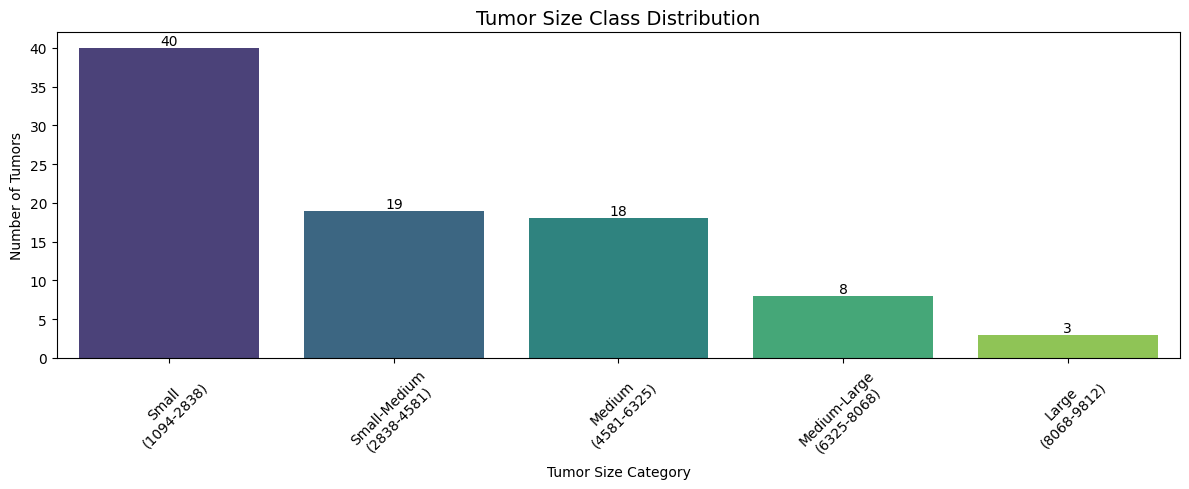

In [137]:
tumor_sizes = []

min_tumor_area = 1000

for mask in mask_list:

    gray_mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(
        gray_mask,
        127,
        255,
        cv2.THRESH_BINARY
    )

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    largest_area = 0

    for cnt in contours:

        area = cv2.contourArea(cnt)

        if area > largest_area:
            largest_area = area

    if largest_area > min_tumor_area:
        tumor_sizes.append(largest_area)

tumor_sizes_df = pd.DataFrame({
    'Tumor Size': tumor_sizes
})

# Create bins
bins = np.linspace(
    tumor_sizes_df['Tumor Size'].min(),
    tumor_sizes_df['Tumor Size'].max(),
    6
)

labels = []

size_names = [
    'Small',
    'Small-Medium',
    'Medium',
    'Medium-Large',
    'Large'
]

for i in range(len(bins)-1):

    labels.append(
        f"{size_names[i]}\n({int(bins[i])}-{int(bins[i+1])})"
    )

tumor_sizes_df['Size Class'] = pd.cut(
    tumor_sizes_df['Tumor Size'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

plt.figure(figsize=(12,5))

ax = sns.countplot(
    x='Size Class',
    data=tumor_sizes_df,
    palette='viridis'
)

plt.title(
    "Tumor Size Class Distribution",
    fontsize=14
)

plt.xlabel("Tumor Size Category")
plt.ylabel("Number of Tumors")

plt.xticks(rotation=45)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.show()

/tmp/ipykernel_15735/1537040049.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


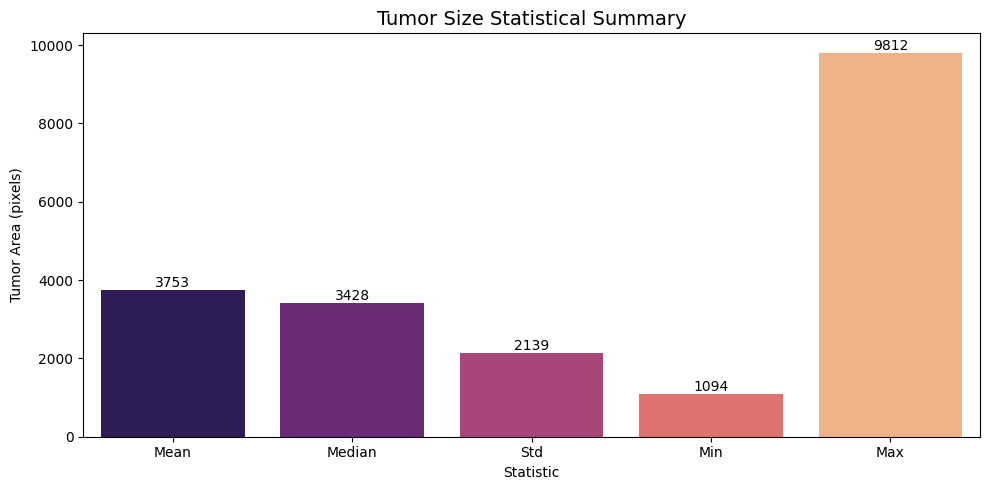

In [138]:
stats_df = pd.DataFrame({
    'Statistic': [
        'Mean',
        'Median',
        'Std',
        'Min',
        'Max'
    ],
    'Value': [
        np.mean(tumor_sizes),
        np.median(tumor_sizes),
        np.std(tumor_sizes),
        np.min(tumor_sizes),
        np.max(tumor_sizes)
    ]
})

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x='Statistic',
    y='Value',
    data=stats_df,
    palette='magma'
)

plt.title(
    "Tumor Size Statistical Summary",
    fontsize=14
)

plt.xlabel("Statistic")
plt.ylabel("Tumor Area (pixels)")

# Add values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f'
    )

plt.tight_layout()

plt.show()

/tmp/ipykernel_15735/3812981433.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


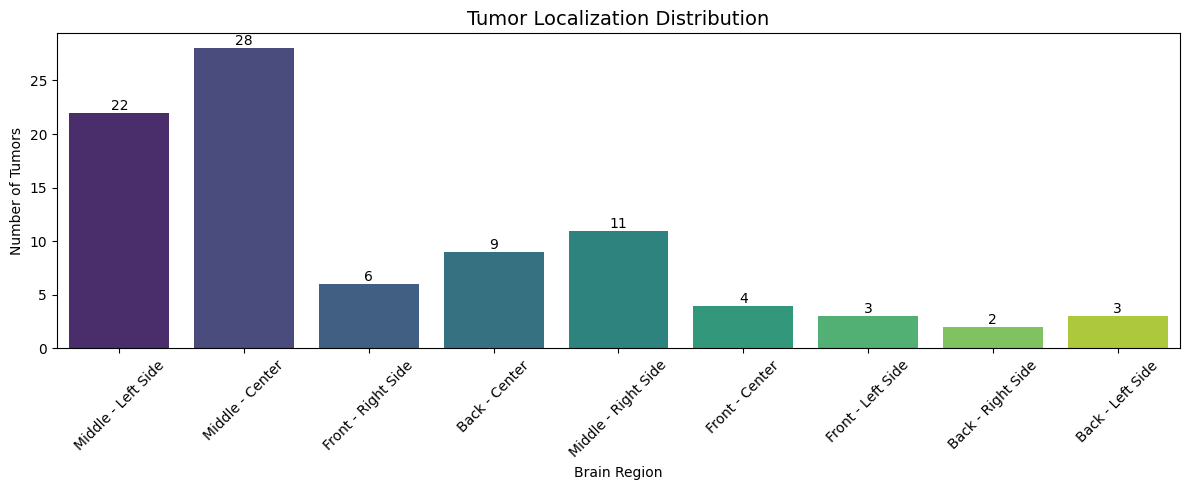

In [139]:
tumor_locations = []

min_tumor_area = 1000

for mask in mask_list:

    gray_mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(
        gray_mask,
        127,
        255,
        cv2.THRESH_BINARY
    )

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        continue

    largest_contour = max(
        contours,
        key=cv2.contourArea
    )

    largest_area = cv2.contourArea(
        largest_contour
    )

    if largest_area < min_tumor_area:
        continue

    M = cv2.moments(largest_contour)

    if M["m00"] == 0:
        continue

    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])

    h, w = gray_mask.shape

    horizontal = ""
    vertical = ""

    # Horizontal position
    if cx < w * 0.33:
        horizontal = "Left Side"
    elif cx > w * 0.66:
        horizontal = "Right Side"
    else:
        horizontal = "Center"

    # Vertical position
    if cy < h * 0.33:
        vertical = "Front"
    elif cy > h * 0.66:
        vertical = "Back"
    else:
        vertical = "Middle"

    location = f"{vertical} - {horizontal}"

    tumor_locations.append(location)

location_df = pd.DataFrame({
    'Tumor Location': tumor_locations
})

plt.figure(figsize=(12,5))

ax = sns.countplot(
    x='Tumor Location',
    data=location_df,
    palette='viridis'
)

plt.title(
    "Tumor Localization Distribution",
    fontsize=14
)

plt.xlabel("Brain Region")
plt.ylabel("Number of Tumors")

plt.xticks(rotation=45)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.show()

/tmp/ipykernel_15735/1515191125.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


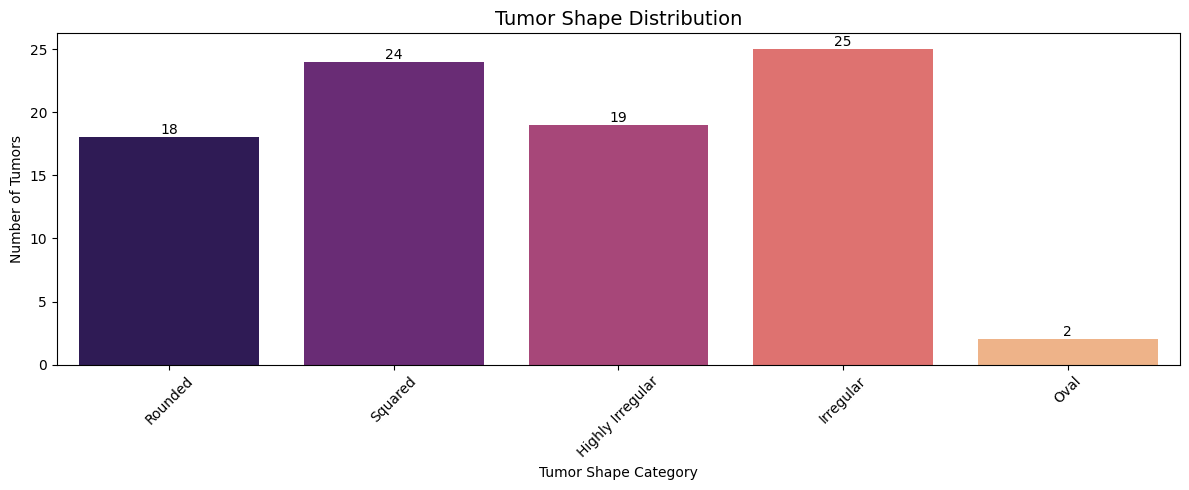

In [143]:
tumor_shapes = []

min_tumor_area = 1000

for mask in mask_list:

    gray_mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(
        gray_mask,
        127,
        255,
        cv2.THRESH_BINARY
    )

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        continue

    largest_contour = max(
        contours,
        key=cv2.contourArea
    )

    area = cv2.contourArea(
        largest_contour
    )

    if area < min_tumor_area:
        continue

    perimeter = cv2.arcLength(
        largest_contour,
        True
    )

    if perimeter == 0:
        continue

    circularity = (
        4 * np.pi * area
    ) / (perimeter ** 2)

    # Bounding box
    x, y, w, h = cv2.boundingRect(
        largest_contour
    )

    aspect_ratio = w / h

    # Polygon approximation
    approx = cv2.approxPolyDP(
        largest_contour,
        0.04 * perimeter,
        True
    )

    vertices = len(approx)

    # Shape classification
    if vertices == 4:
        shape = 'Squared'

    elif circularity >= 0.88:
        shape = 'Circular'

    elif circularity >= 0.72:

        if aspect_ratio > 1.3 or aspect_ratio < 0.7:
            shape = 'Oval'
        else:
            shape = 'Rounded'

    elif circularity >= 0.50:
        shape = 'Irregular'

    else:
        shape = 'Highly Irregular'

    tumor_shapes.append(shape)

shape_df = pd.DataFrame({
    'Tumor Shape': tumor_shapes
})

plt.figure(figsize=(12,5))

ax = sns.countplot(
    x='Tumor Shape',
    data=shape_df,
    palette='magma'
)

plt.title(
    "Tumor Shape Distribution",
    fontsize=14
)

plt.xlabel("Tumor Shape Category")
plt.ylabel("Number of Tumors")

plt.xticks(rotation=45)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.show()

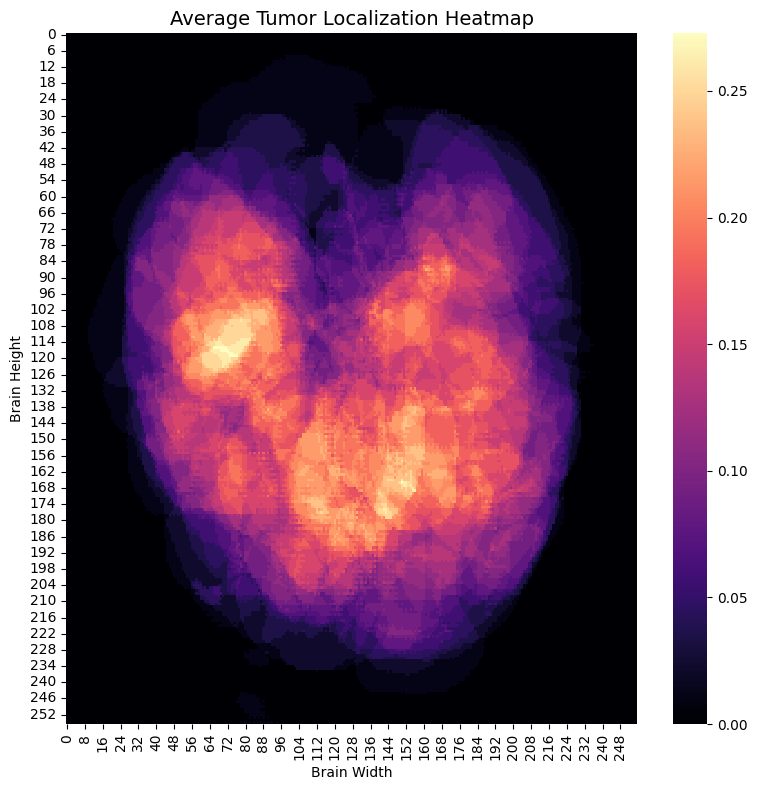

In [144]:
heatmap_masks = []

min_tumor_area = 1000

for mask in mask_list:

    gray_mask = cv2.cvtColor(
        mask,
        cv2.COLOR_BGR2GRAY
    )

    _, thresh = cv2.threshold(
        gray_mask,
        127,
        255,
        cv2.THRESH_BINARY
    )

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        continue

    largest_contour = max(
        contours,
        key=cv2.contourArea
    )

    area = cv2.contourArea(
        largest_contour
    )

    if area < min_tumor_area:
        continue

    binary_mask = (
        thresh > 0
    ).astype(np.float32)

    heatmap_masks.append(binary_mask)

# Average localization map
mean_heatmap = np.mean(
    heatmap_masks,
    axis=0
)

plt.figure(figsize=(8,8))

sns.heatmap(
    mean_heatmap,
    cmap='magma',
    cbar=True
)

plt.title(
    "Average Tumor Localization Heatmap",
    fontsize=14
)

plt.xlabel("Brain Width")
plt.ylabel("Brain Height")

plt.tight_layout()

plt.show()